In [20]:
import sys
import os
import libcontext

In [21]:
import torch
import numpy as np
from typing import cast, List, Optional, Union
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import time
import math

from torch.optim import Optimizer

In [22]:
def update_uv_with_brand(U, Sigma, V, beta_g, g_bar_col, max_rank):
    # orthogonalizing new columns
    u_residual = beta_g - U @ (U.T @ beta_g)
    v_residual = g_bar_col - V @ (V.T @ g_bar_col)
    
    u_residual_norm = torch.norm(u_residual, p=2)
    v_residual_norm = torch.norm(v_residual, p=2)
    
    if u_residual_norm > 1e-8:
        u_residual = u_residual / u_residual_norm
    else:
        u_residual = torch.zeros_like(u_residual)
    
    if v_residual_norm > 1e-8:
        v_residual = v_residual / v_residual_norm
    else:
        v_residual = torch.zeros_like(v_residual)

    # intermidiate matrix M
    B = torch.cat([U.T @ beta_g, u_residual_norm.unsqueeze(0).unsqueeze(1)], dim=0)  # (r+1, 1)
    C = torch.cat([V.T @ g_bar_col, v_residual_norm.unsqueeze(0).unsqueeze(1)], dim=0)  # (r+1, 1)
    M = torch.diag(torch.cat([Sigma, torch.zeros(1, device=U.device)])) + B @ C.T  # (r+1, r+1)

    # compute SVD
    U_m, S_m, V_m = torch.linalg.svd(M, full_matrices=False)

    k = min(max_rank, len(S_m)) if max_rank is not None else len(S_m)
    U_m, S_m, V_m = U_m[:, :k], S_m[:k], V_m[:k, :]

    U = torch.cat([U, u_residual], dim=1) @ U_m
    V = torch.cat([V, v_residual], dim=1) @ V_m
    Sigma = S_m
    return U, Sigma, V

In [23]:
from src.adagram import AdaGram
from src.adagram_fixed_rank import AdaGramFR
from src.shampoo import Shampoo
from src.full_matrix import FullMatrixAdaGrad

## Models

In [24]:
from torch import nn


class LinearRegressionModel(nn.Module):
    def __init__(self, dim_in, dim_out, seed=100):
        super(LinearRegressionModel, self).__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.linear = nn.Linear(dim_in, dim_out)
    
    def forward(self, x):
        return self.linear(x)
    

class MultiClassLogisticRegressionModel(nn.Module):
    def __init__(self, num_classes=2, dim=2):
        super(MultiClassLogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(dim, num_classes)
        self.softmax = nn.Softmax(dim=1)
    def forward(self, x):
        return self.softmax(self.linear(x))
    
    
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim=2, seed=100):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x) 

## Train

In [26]:
import os
import numpy as np
import torch

def train_model(model, optimizer, criterion, results, X_train, y_train, X_test, y_test, 
                num_epochs, opt_name, lr, time_start=None, r=None, use_tqdm=True, grad_save_dir='gradients'):
    """
    Train a model and evaluate on test data, saving gradients by epoch.
    """
    from tqdm import tqdm
    import time
    
    # Create directory for saving gradients
    if not os.path.exists(grad_save_dir):
        os.makedirs(grad_save_dir)

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)
                                                                                                                             
    if time_start is None:
        time_start = time.time()
    
    for epoch in epoch_iterator:
        model.train()
        start_epoch = time.time()
        optimizer.zero_grad()
        y_pred = model(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()

        # Access and save gradients after backward() but before optimizer.step()
        grad_dict = {}
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_dict[name] = param.grad.detach().cpu().numpy()

        # Save gradients to compressed numpy file per epoch
        grad_filename = f'{opt_name}_lr{lr}_epoch{epoch}'
        if r is not None:
            grad_filename += f'_rank{r}'
        grad_file = os.path.join(grad_save_dir, f'{grad_filename}.npz')
        np.savez_compressed(grad_file, **grad_dict)

        optimizer.step()

        elapsed_time = time.time() - time_start
        epoch_time = time.time() - start_epoch

        avg_epoch_time = elapsed_time / (epoch + 1)
        
        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': train_loss.detach().cpu().numpy(),
            'rank': r,
            'avg_epoch_time': avg_epoch_time,
            'epoch_time': epoch_time
        })

    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()
    
    return results, test_loss


## Data generation 

In [27]:
def create_sparse_toy_data(n_samples=1000, in_dim=20, out_dim=1):
    """
    Create toy data where only 2-3 features are truly important,
    and these important features are sparse (mostly zero).
    """
    X = torch.zeros(n_samples, in_dim)
    
    # Feature 1: Very sparse but highly predictive (appears in 5% of samples)
    sparse_mask_1 = torch.rand(n_samples) < 0.05
    X[sparse_mask_1, 0] = torch.randn(sparse_mask_1.sum()) * 3
    
    # Feature 2: Moderately sparse but important (appears in 15% of samples)
    sparse_mask_2 = torch.rand(n_samples) < 0.15
    X[sparse_mask_2, 1] = torch.randn(sparse_mask_2.sum()) * 2
    
    # Features 3-5: Dense but less important (noise features)
    X[:, 2:5] = torch.randn(n_samples, 3) * 0.5
    
    # Remaining features: Pure noise
    X[:, 5:] = torch.randn(n_samples, in_dim-5) * 0.1
    
    # Create target: heavily dependent on sparse features
    y = (2.0 * X[:, 0] +           # Sparse feature 1 (high weight)
         1.5 * X[:, 1] +           # Sparse feature 2 (medium weight)
         0.3 * X[:, 2:5].sum(dim=1) +  # Dense features (low weight)
         torch.randn(n_samples) * 0.1)  # Small noise
    
    # Convert to binary classification
    y = (y > y.median()).long()
    
    return X, y

def generate_data(n_samples=100, in_channels=1, out_channels=1, noise=0.1):
    """
    Generate synthetic data for multi-dimensional linear regression.
    
    Args:
        n_samples (int): Number of samples.
        in_channels (int): Input dimension (features per sample).
        out_channels (int): Output dimension (targets per sample).
        noise (float): Magnitude of Gaussian noise added to outputs.
    
    Returns:
        X (torch.Tensor): Input data of shape (n_samples, in_channels).
        y (torch.Tensor): Output data of shape (n_samples, out_channels).
    """
    # Random input data (uniformly distributed in [0, 10])
    X = torch.rand(n_samples, in_channels) * 10
    
    # True weights (slopes) and biases (intercepts)
    true_weights = torch.randn(in_channels, out_channels) * 2  # Random slopes
    cond_number = torch.linalg.cond(true_weights)
    print("cond_number:", cond_number)
    true_bias = torch.randn(out_channels) * 1                  # Random biases
    
    # Linear transformation: y = X @ true_weights + true_bias + noise
    y = X @ true_weights + true_bias
    
    # Add Gaussian noise
    y += noise * torch.randn(n_samples, out_channels)
    
    return X, y, true_weights, true_bias


def generate_correlated_data(n_samples=100, in_channels=1, out_channels=1, noise=0.1, correlation_strength=0.7):
    """
    Generate synthetic data with correlated input features.
    
    Args:
        n_samples (int): Number of samples.
        in_channels (int): Input dimension (features per sample).
        out_channels (int): Output dimension (targets per sample).
        noise (float): Magnitude of Gaussian noise added to outputs.
        correlation_strength (float): Correlation between input features (0-1).
    
    Returns:
        X (torch.Tensor): Correlated input data of shape (n_samples, in_channels).
        y (torch.Tensor): Output data of shape (n_samples, out_channels).
    """
    # Create correlation matrix for input features
    correlation_matrix = torch.full((in_channels, in_channels), correlation_strength)
    correlation_matrix.fill_diagonal_(1.0)
    
    # Generate correlated input data using multivariate normal distribution
    mean = torch.zeros(in_channels)
    X_correlated = torch.distributions.MultivariateNormal(mean, correlation_matrix).sample((n_samples,))
    
    # Scale and shift to desired range [0, 10]
    X = (X_correlated - X_correlated.min()) / (X_correlated.max() - X_correlated.min()) * 10
    
    # True weights and biases
    true_weights = torch.randn(in_channels, out_channels) * 2
    true_bias = torch.randn(out_channels) * 1
    
    # Linear transformation with noise
    y = X @ true_weights + true_bias + noise * torch.randn(n_samples, out_channels)
    
    return X, y, true_weights, true_bias

## Pipeline

In [28]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

learning_rates = [0.01]
num_epochs = 1000
ranks = [10]
in_dims = [20]
out_dims = [1]

X, y = create_sparse_toy_data(n_samples=2000, in_dim=in_dims[0], out_dim=out_dims[0])
print("cond", torch.linalg.cond(X))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
optimizers = {
    # 'Shampoo': lambda params, lr: Shampoo(params, lr=lr),
    # 'FullMatrixAdaGrad': lambda params, lr: FullMatrixAdaGrad(params, lr=lr),
    'AdaGramFR': lambda params, lr, max_rank: AdaGramFR(params, lr=lr, max_rank=max_rank),
    'Vanilla_SGD': lambda params, lr: torch.optim.SGD(params, lr=lr),
    'Torch_Adagrad': lambda params, lr: torch.optim.Adagrad(params, lr=lr),
}
models = {}
all_train_losses = {}
all_test_losses = {}
results = []

for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
        criterion = nn.CrossEntropyLoss()
        print(opt_name)
        if opt_name == "AdaGramFR":
            for rank in ranks:
                model = SimpleClassifier(input_dim=in_dims[0], output_dim=2, seed=100)
                optimizer = opt_fn(model.parameters(), lr, max_rank=rank)
                epoch_results, test_loss = train_model(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr, 
                    r=rank
                )
        else:
            model = SimpleClassifier(input_dim=in_dims[0], output_dim=2, seed=100)
            optimizer = opt_fn(model.parameters(), lr)
            epoch_results, test_loss = train_model(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr, 
                )
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
df.to_csv(f'all_algos_{in_dims[0]}_by_{out_dims[0]}.csv')
# print(f"end {dim}")


cond tensor(8.4044)
AdaGramFR


100%|██████████| 1000/1000 [00:16<00:00, 60.22it/s]


Vanilla_SGD


100%|██████████| 1000/1000 [00:04<00:00, 226.12it/s]


Torch_Adagrad


100%|██████████| 1000/1000 [00:05<00:00, 186.97it/s]


In [9]:
loaded_matrix = torch.load('error_matrix.pt')
loaded_matrix.shape

torch.Size([40, 11])

## Adagram Statistics

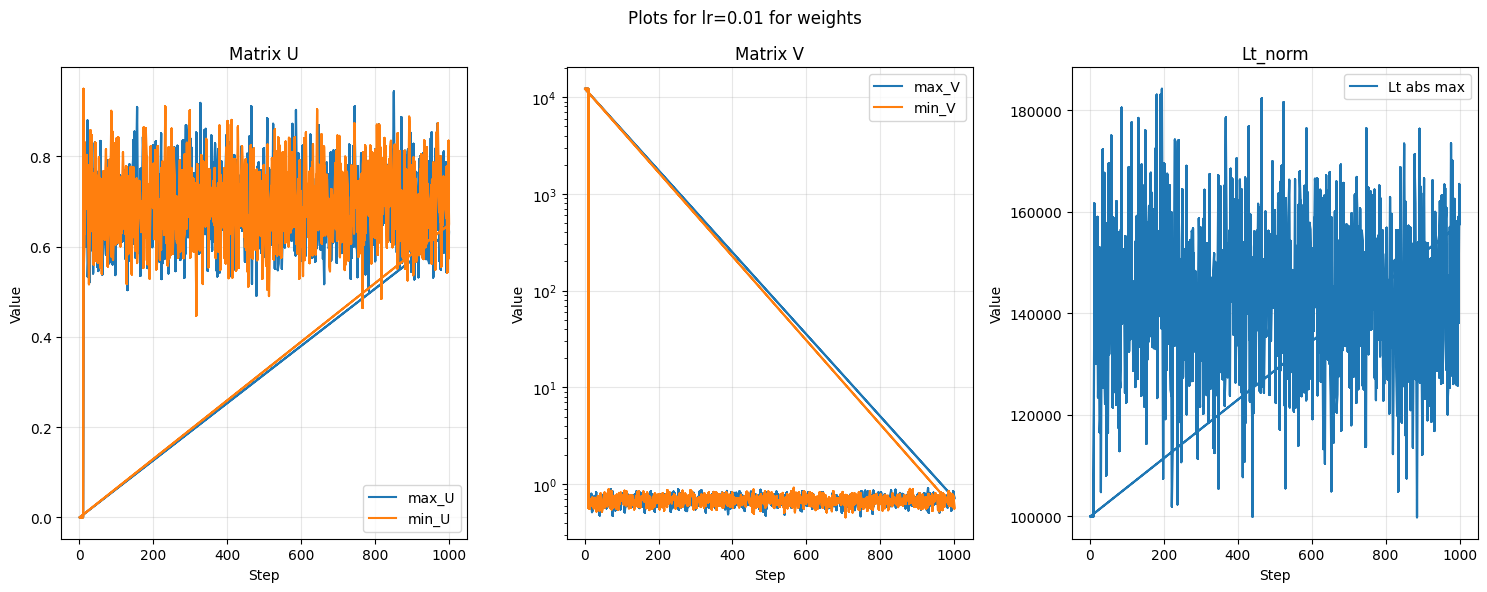

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('adagram_logs.csv')
lr_values = df['lr'].unique()
param_id = 0
params = {0:"weights", 1:"bias"}

for lr in lr_values:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
    subset = df[df['lr'] == lr]
    # for param in subset['param_id'].unique():
    param_subset = subset[subset['param_id'] == param_id]
    # ax1.scatter(param_subset['step'], param_subset['max_U'], label=f'max_U (param {param})')
    # ax1.scatter(param_subset['step'], param_subset['min_U'], label=f'min_U (param {param})')
    # ax2.scatter(param_subset['step'], param_subset['max_V'], label=f'max_V (param {param})')
    # ax2.scatter(param_subset['step'], param_subset['min_V'], label=f'min_V (param {param})')
    # ax3.scatter(param_subset['step'], param_subset['grad_norm'], label=f'grad_norm (param {param})')
    ax1.plot(param_subset['step'], np.abs(param_subset['max_U']), label=f'max_U')
    ax1.plot(param_subset['step'], np.abs(param_subset['min_U']), label=f'min_U')
    ax2.plot(param_subset['step'], np.abs(param_subset['max_V']), label=f'max_V')
    ax2.plot(param_subset['step'], np.abs(param_subset['min_V']), label=f'min_V')
    # ax1.scatter(param_subset['step'], param_subset['grad_std'], label=f'grad_norm')
    ax3.plot(param_subset['step'], param_subset['Lt_norm'], label=f'Lt abs max')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Value')
    ax1.set_title('Matrix U')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Step')
    ax2.set_ylabel('Value')
    ax2.set_title('Matrix V')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale("log") 

    ax3.set_xlabel('Step')
    ax3.set_ylabel('Value')
    ax3.set_title('Lt_norm')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f'Plots for lr={lr} for {params[param_id]}')
    plt.tight_layout()
    plt.show()


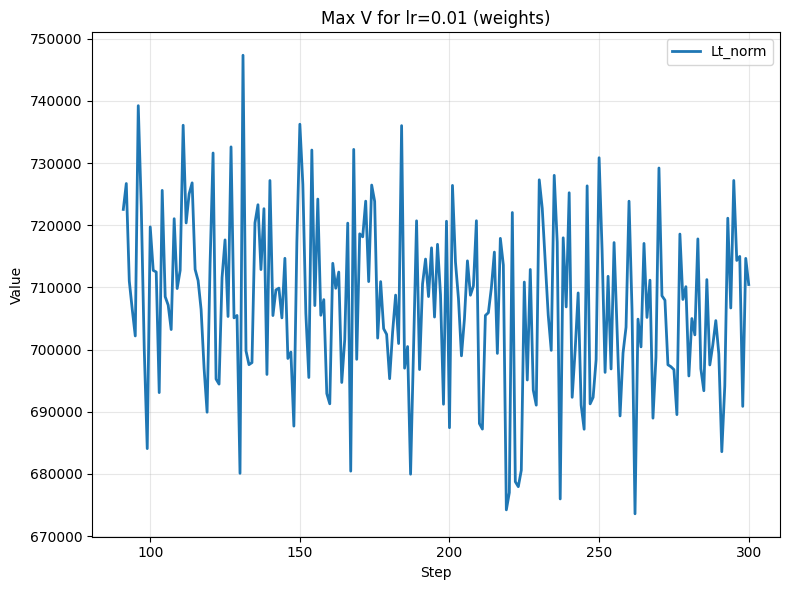

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('adagram_logs.csv')
lr_values = df['lr'].unique()
param_id = 0
params = {0:"weights", 1:"bias"}

for lr in lr_values:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    subset = df[df['lr'] == lr]
    param_subset = subset[subset['param_id'] == param_id]
    param_subset = param_subset[param_subset['step'] > 90]
    
    ax.plot(param_subset['step'], param_subset['Lt_norm'], label='Lt_norm', linewidth=2)
    # ax.plot(param_subset['step'], param_subset['min_V'], label='min_V', linewidth=2)
    
    ax.set_xlabel('Step')
    ax.set_ylabel('Value')
    ax.set_title(f'Max V for lr={lr} ({params[param_id]})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Convergence

In [30]:
df = pd.read_csv(f'all_algos_{in_dims[0]}_by_{out_dims[0]}.csv')
df['loss'] = df['loss'].astype(float)
df.head()


,Unnamed: 0,epoch,optimizer,lr,loss,rank,avg_epoch_time,epoch_time
0,0,0,AdaGramFR rank 10,0.01,0.675067,10.0,0.030727,0.030727
1,1,1,AdaGramFR rank 10,0.01,0.671649,10.0,0.020524,0.010321
2,2,2,AdaGramFR rank 10,0.01,0.668302,10.0,0.016700,0.009053
3,3,3,AdaGramFR rank 10,0.01,0.665025,10.0,0.012954,0.001717
4,4,4,AdaGramFR rank 10,0.01,0.661818,10.0,0.013988,0.018120


<Figure size 1500x800 with 0 Axes>

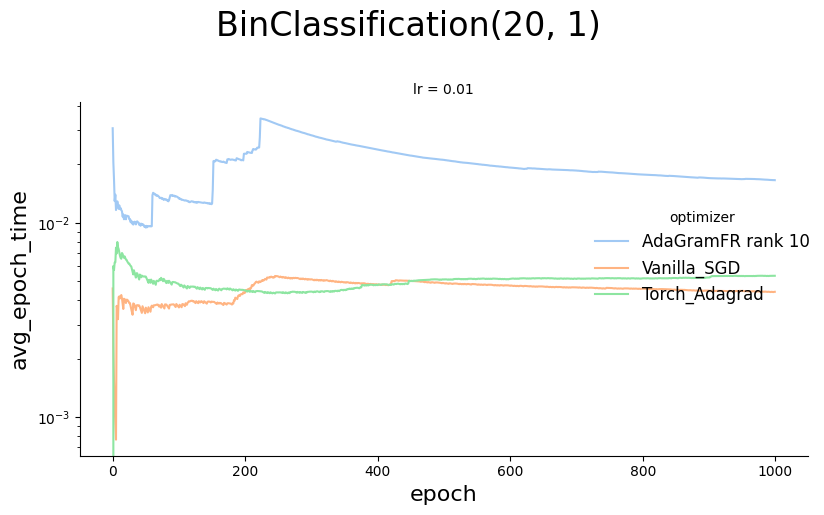

In [32]:
plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df,
    col='lr',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='epoch',
    y='avg_epoch_time',
    hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='optimizer', title_fontsize='15', fontsize='12')

grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
                  fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="lr = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()

## Weights 

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_theme(style="whitegrid")

# Configuration
grad_dir = 'gradients'
optimizers = ['Torch_Adagrad', 'Vanilla_SGD', 'AdaGramFR']
lr_values = [0.01]
param_names = ['linear.weight', 'linear.bias']
ranks = [10]  # Add this for AdaGramFR
start_epoch = 0
end_epoch = 300

def clean_gradient_values(grad_values, max_value=1e17):
    """Clean gradient values by handling infinite and very large values."""
    grad_clean = np.array(grad_values)
    # Replace positive infinity
    grad_clean = np.where(np.isposinf(grad_clean), max_value, grad_clean)
    # Replace negative infinity  
    grad_clean = np.where(np.isneginf(grad_clean), -max_value, grad_clean)
    # Replace NaN values with 0
    grad_clean = np.where(np.isnan(grad_clean), 0, grad_clean)
    return grad_clean

def collect_all_gradient_values(optimizer, lr, param_name, start_epoch=0, end_epoch=300, rank=None):
    """Collect all gradient values from all epochs for a specific parameter."""
    all_grad_values = []
    epochs_found = 0
    
    for epoch in range(start_epoch, end_epoch + 1):
        if rank is not None:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}_rank{rank}.npz')
        else:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}.npz')
            
        if os.path.exists(grad_file):
            try:
                epoch_gradients = np.load(grad_file)
                if param_name in epoch_gradients:
                    grad = epoch_gradients[param_name]
                    # Flatten the gradient array and extend the list
                    all_grad_values.extend(grad.flatten())
                    epochs_found += 1
                    
                    # Print statistics for first few epochs
                    if epoch < 3:
                        print(f"Epoch {epoch} - {param_name}: Shape {grad.shape}, "
                              f"Values added: {grad.size}")
                
                epoch_gradients.close()
            except Exception as e:
                print(f"Error reading {grad_file}: {e}")
                continue
        else:
            if epoch < 3:  # Only print missing files for first few epochs
                print(f"Missing file: {grad_file}")
    
    print(f"Total epochs found: {epochs_found}, Total gradient values: {len(all_grad_values)}")
    return np.array(all_grad_values)

# Dictionary to store all gradient values
gradient_collections = {}

# Collect gradient values for all optimizers and parameters
for optimizer in optimizers:
    for lr in lr_values:
        for param_name in param_names:
            print(f"\n{'='*60}")
            print(f"Collecting gradients for {optimizer}, lr={lr}, param={param_name}")
            
            if optimizer == 'AdaGramFR':
                for r in ranks:
                    key = f"{optimizer}_rank{r}_lr{lr}_{param_name}"
                    grad_values = collect_all_gradient_values(
                        optimizer, lr, param_name, start_epoch, end_epoch, rank=r
                    )
                    if len(grad_values) > 0:
                        gradient_collections[key] = clean_gradient_values(grad_values)
                        print(f"Stored {len(gradient_collections[key])} values for {key}")
            else:
                key = f"{optimizer}_lr{lr}_{param_name}"
                grad_values = collect_all_gradient_values(
                    optimizer, lr, param_name, start_epoch, end_epoch
                )
                if len(grad_values) > 0:
                    gradient_collections[key] = clean_gradient_values(grad_values)
                    print(f"Stored {len(gradient_collections[key])} values for {key}")

# Create comprehensive histograms using Seaborn
if gradient_collections:
    print(f"\n{'='*60}")
    print("Creating histograms...")
    
    # Separate collections by parameter type
    weight_collections = {k: v for k, v in gradient_collections.items() if 'linear.weight' in k}
    bias_collections = {k: v for k, v in gradient_collections.items() if 'linear.bias' in k}
    
    # Plot histograms for weights using Seaborn
    if weight_collections:
        n_weight_collections = len(weight_collections)
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        axes = axes.flatten()
        fig.suptitle('Gradient Histograms for Weights (linear.weight)', fontsize=16)
        
        colors = ['blue', 'red', 'green', 'orange', 'purple']
        
        # Individual histograms for each optimizer
        for idx, (key, values) in enumerate(weight_collections.items()):
            if idx < len(axes):
                # Create DataFrame for seaborn
                df_temp = pd.DataFrame({'gradient_values': values, 'optimizer': key})
                
                sns.histplot(data=df_temp, x='gradient_values', bins=50, 
                           color=colors[idx % len(colors)], alpha=0.7, 
                           stat='density', ax=axes[idx])
                
                axes[idx].set_xlabel('Gradient Value')
                axes[idx].set_ylabel('Density')
                axes[idx].set_title(f'Weight Gradients: {key}')
                axes[idx].grid(True, alpha=0.3)
                
                print(f"Weight gradients for {key}: "
                      f"Mean={np.mean(values):.6f}, Std={np.std(values):.6f}, "
                      f"Min={np.min(values):.6f}, Max={np.max(values):.6f}")
        
        # Hide unused subplots
        for idx in range(n_weight_collections, len(axes)):
            axes[idx].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
        # Overlapping histogram for weights comparison using Seaborn
        plt.figure(figsize=(8, 5))
        
        # Combine all weight data into a single DataFrame
        combined_weight_data = []
        for key, values in weight_collections.items():
            temp_df = pd.DataFrame({
                'gradient_values': values,
                'optimizer': key
            })
            combined_weight_data.append(temp_df)
        
        if combined_weight_data:
            weight_df = pd.concat(combined_weight_data, ignore_index=True)
            
            sns.histplot(data=weight_df, x='gradient_values', hue='optimizer', 
                        bins=50, alpha=0.6, stat='density', multiple='layer')
            
            plt.xlabel('Gradient Value')
            plt.ylabel('Density')
            plt.title('Weight Gradients Comparison (All Optimizers)')
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # Plot histograms for biases using Seaborn
    if bias_collections:
        n_bias_collections = len(bias_collections)
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        axes = axes.flatten()
        fig.suptitle('Gradient Histograms for Biases (linear.bias)', fontsize=16)
        
        # Individual histograms for each optimizer
        for idx, (key, values) in enumerate(bias_collections.items()):
            if idx < len(axes):
                # Create DataFrame for seaborn
                df_temp = pd.DataFrame({'gradient_values': values, 'optimizer': key})
                
                sns.histplot(data=df_temp, x='gradient_values', bins=50, 
                           color=colors[idx % len(colors)], alpha=0.7, 
                           stat='density', ax=axes[idx])
                
                axes[idx].set_xlabel('Gradient Value')
                axes[idx].set_ylabel('Density')
                axes[idx].set_title(f'Bias Gradients: {key}')
                axes[idx].grid(True, alpha=0.3)
                
                print(f"Bias gradients for {key}: "
                      f"Mean={np.mean(values):.6f}, Std={np.std(values):.6f}, "
                      f"Min={np.min(values):.6f}, Max={np.max(values):.6f}")
        
        # Hide unused subplots
        for idx in range(n_bias_collections, len(axes)):
            axes[idx].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
        # Overlapping histogram for biases comparison using Seaborn
        plt.figure(figsize=(8, 5))
        
        # Combine all bias data into a single DataFrame
        combined_bias_data = []
        for key, values in bias_collections.items():
            temp_df = pd.DataFrame({
                'gradient_values': values,
                'optimizer': key
            })
            combined_bias_data.append(temp_df)
        
        if combined_bias_data:
            bias_df = pd.concat(combined_bias_data, ignore_index=True)
            
            sns.histplot(data=bias_df, x='gradient_values', hue='optimizer', 
                        bins=50, alpha=0.6, stat='density', multiple='layer')
            
            plt.xlabel('Gradient Value')
            plt.ylabel('Density')
            plt.title('Bias Gradients Comparison (All Optimizers)')
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # Save gradient statistics
    stats_data = []
    for key, values in gradient_collections.items():
        stats_data.append({
            'collection': key,
            'total_values': len(values),
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values),
            'median': np.median(values)
        })
    
    stats_df = pd.DataFrame(stats_data)
    stats_df.to_csv('gradient_value_statistics.csv', index=False)
    print(f"\nGradient statistics saved to 'gradient_value_statistics.csv'")
    print(f"Total collections processed: {len(gradient_collections)}")
    
else:
    print("No gradient data found. Please check:")
    print("1. Gradient files exist in the 'gradients' directory")
    print("2. File naming matches the expected pattern")
    print("3. Optimizer names are correct")



Epoch 0 - linear.weight: Shape (2, 20), Values added: 40
Epoch 1 - linear.weight: Shape (2, 20), Values added: 40
Epoch 2 - linear.weight: Shape (2, 20), Values added: 40
Total epochs found: 134, Total gradient values: 5140
Stored 5140 values for Torch_Adagrad_lr0.01_linear.weight

Epoch 0 - linear.bias: Shape (2,), Values added: 2
Epoch 1 - linear.bias: Shape (2,), Values added: 2
Epoch 2 - linear.bias: Shape (2,), Values added: 2
Total epochs found: 134, Total gradient values: 268
Stored 268 values for Torch_Adagrad_lr0.01_linear.bias

Epoch 0 - linear.weight: Shape (2, 20), Values added: 40
Epoch 1 - linear.weight: Shape (2, 20), Values added: 40
Epoch 2 - linear.weight: Shape (2, 20), Values added: 40



Reading gradients for Torch_Adagrad, lr=0.01, param=linear.weight
Epoch 0 - linear.weight:
  Shape: (2, 20)
  Norm: 0.279370
  Std: 0.044172
Epoch 1 - linear.weight:
  Shape: (2, 20)
  Norm: 0.273390
  Std: 0.043227
Epoch 2 - linear.weight:
  Shape: (2, 20)
  Norm: 0.269231
  Std: 0.042569
Epoch 3 - linear.weight:
  Shape: (2, 20)
  Norm: 0.265876
  Std: 0.042039
Epoch 4 - linear.weight:
  Shape: (2, 20)
  Norm: 0.263002
  Std: 0.041584
Successfully read 134 epochs

Reading gradients for Torch_Adagrad, lr=0.01, param=linear.bias
Epoch 0 - linear.bias:
  Shape: (2,)
  Norm: 0.065907
  Std: 0.046603
Epoch 1 - linear.bias:
  Shape: (2,)
  Norm: 0.058915
  Std: 0.041659
Epoch 2 - linear.bias:
  Shape: (2,)
  Norm: 0.054241
  Std: 0.038354
Epoch 3 - linear.bias:
  Shape: (2,)
  Norm: 0.050568
  Std: 0.035757
Epoch 4 - linear.bias:
  Shape: (2,)
  Norm: 0.047487
  Std: 0.033578
Successfully read 134 epochs

Reading gradients for Vanilla_SGD, lr=0.01, param=linear.weight
Epoch 0 - linear.wei

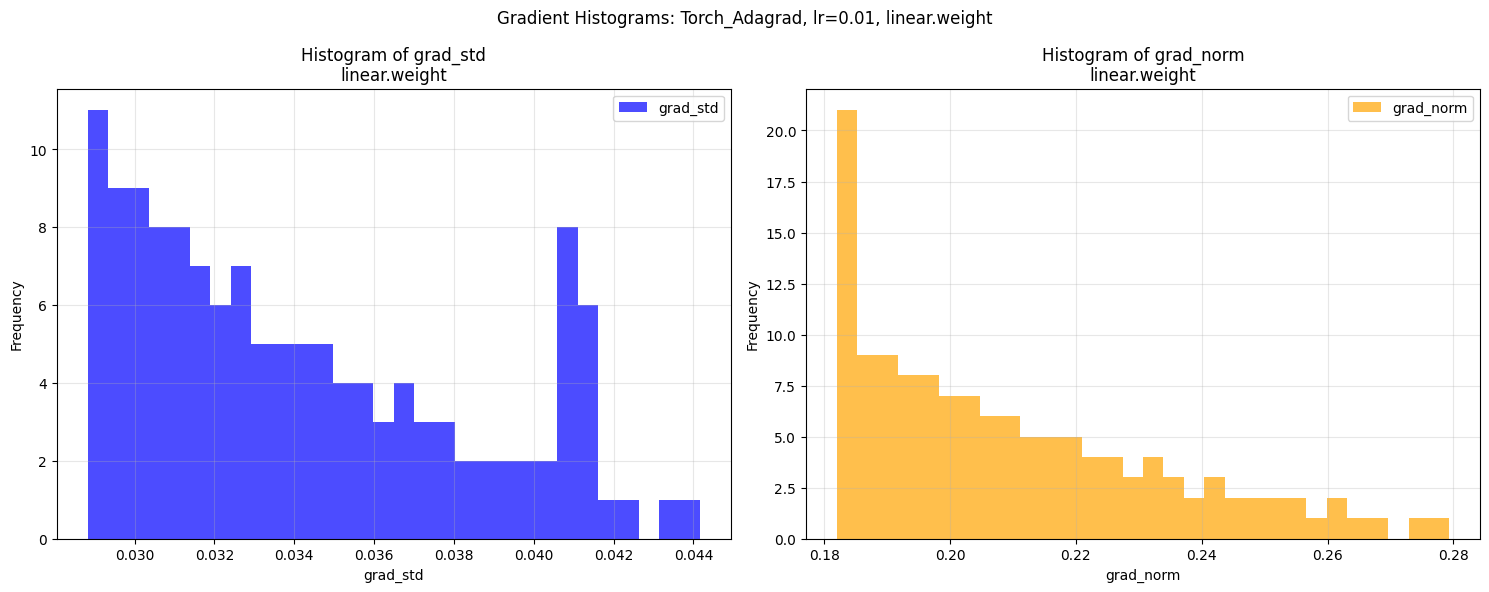

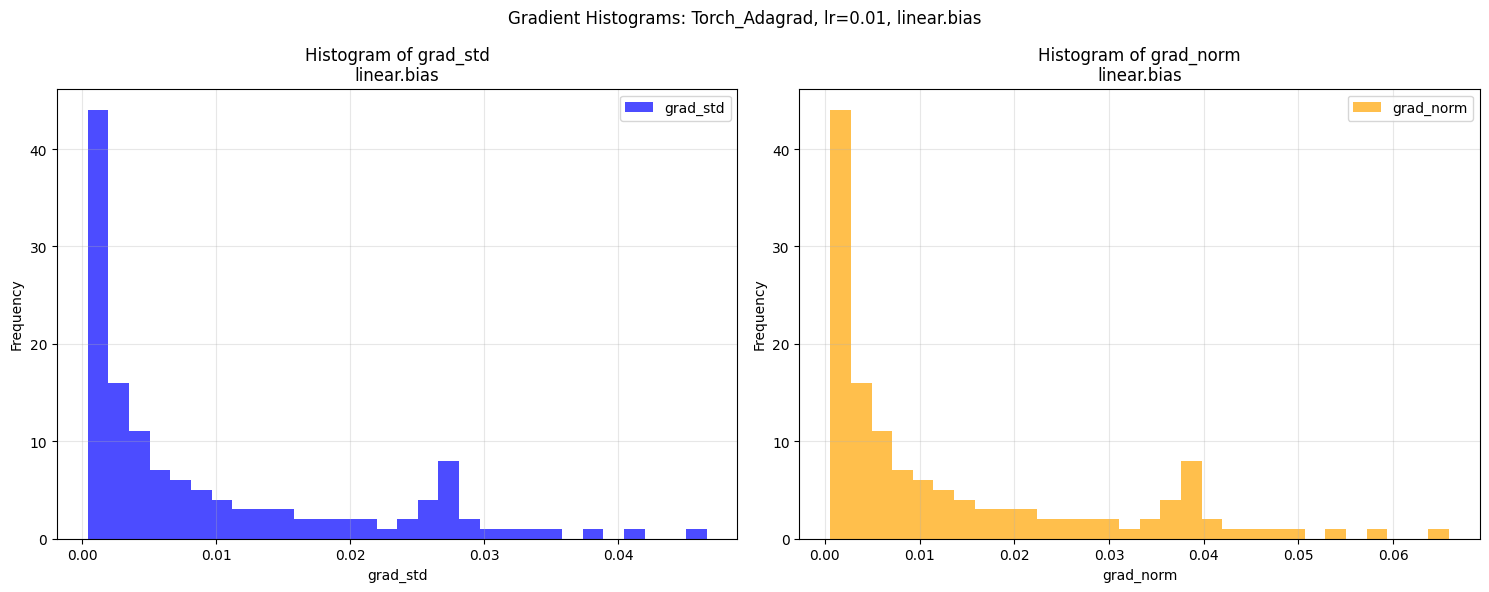

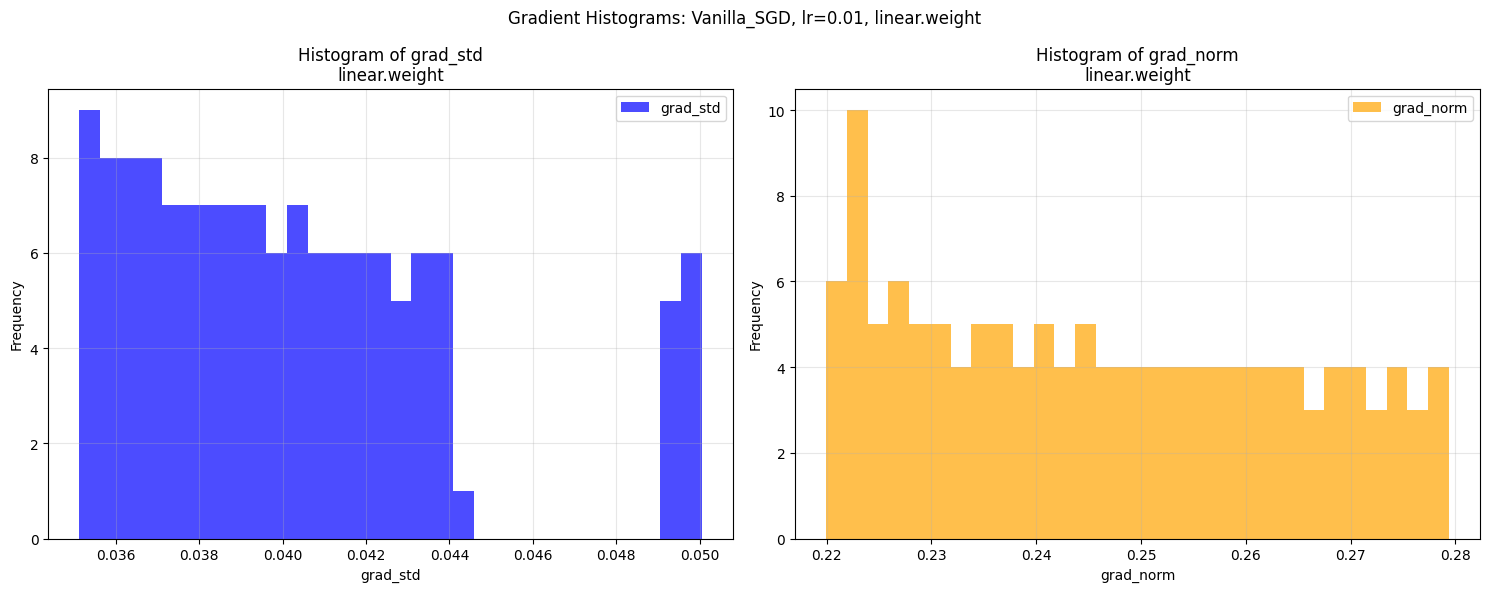

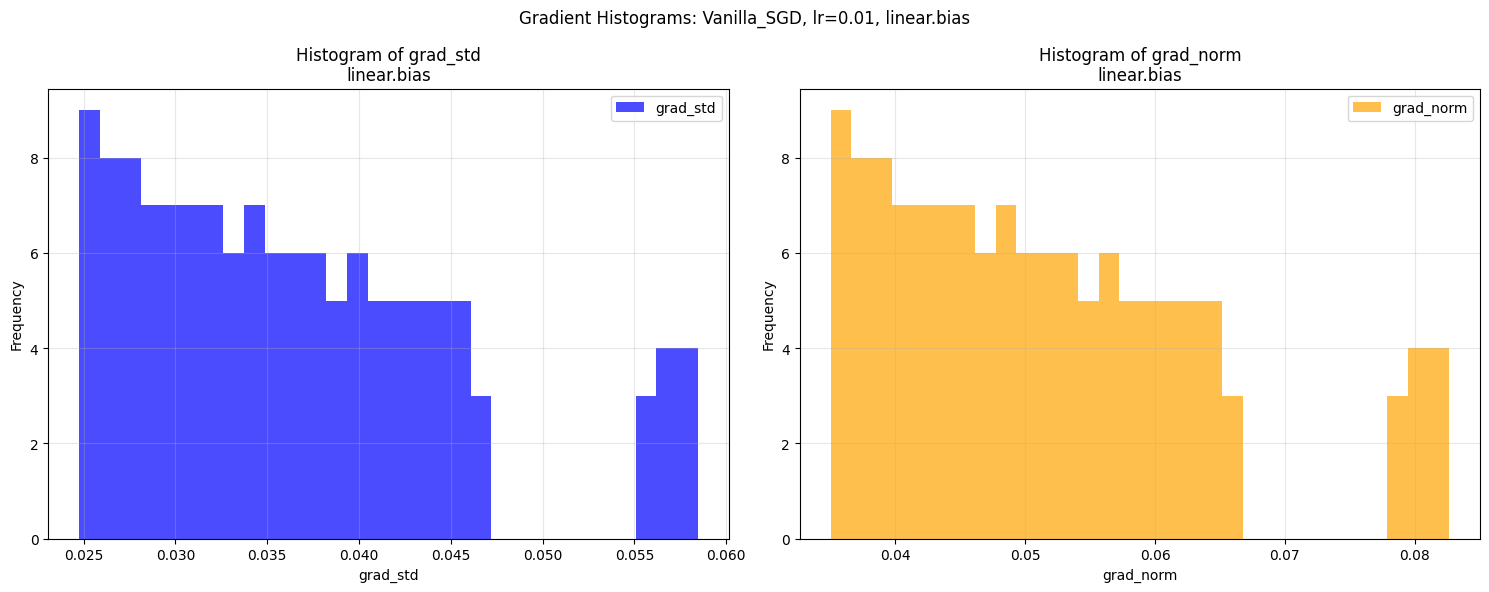

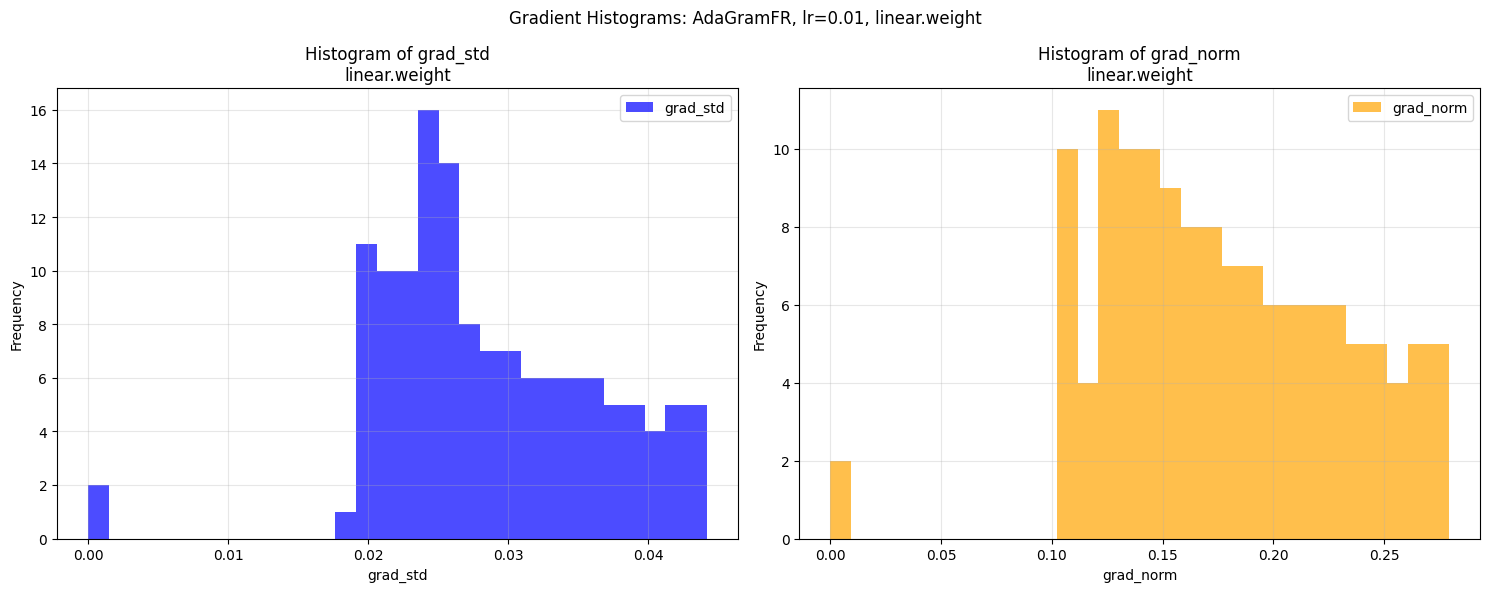

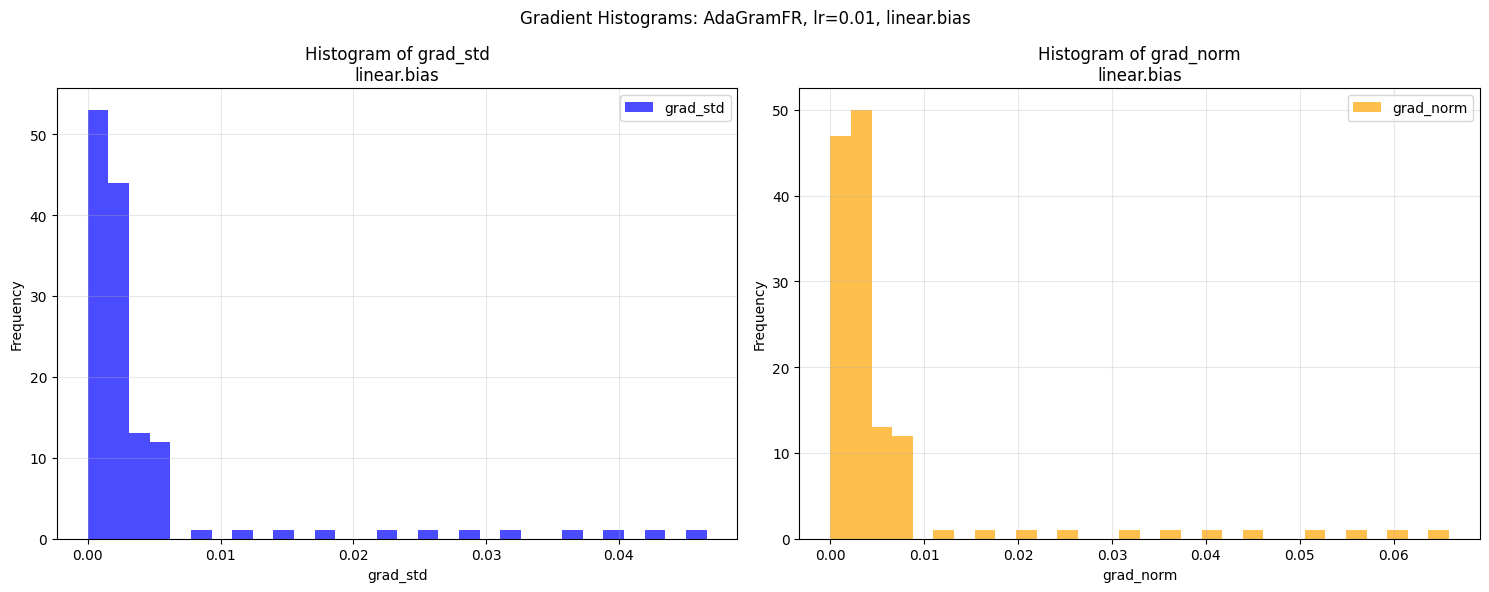


Gradient statistics saved to 'gradient_statistics.csv'


In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
grad_dir = 'gradients'
optimizers = ['Torch_Adagrad', 'Vanilla_SGD', 'AdaGramFR']  # Add your optimizers
lr_values = [0.01]  # Add your learning rates
param_names = ['linear.weight', 'linear.bias']
start_epoch = 0
end_epoch = 300

def clean_gradient_data(df, max_value=1e17):
    """Clean gradient data by handling infinite and very large values."""
    df_clean = df.copy()
    
    # Replace infinite values
    for col in ['grad_norm', 'grad_std']:
        if col in df_clean.columns:
            # Replace positive infinity
            df_clean[col] = np.where(np.isposinf(df_clean[col]), max_value, df_clean[col])
            # Replace negative infinity  
            df_clean[col] = np.where(np.isneginf(df_clean[col]), -max_value, df_clean[col])
            # Replace NaN values with 0
            df_clean[col] = np.where(np.isnan(df_clean[col]), 0, df_clean[col])
    
    return df_clean


# Function to read gradients for all epochs
def read_gradient_stats(optimizer, lr, param_name, start_epoch=0, end_epoch=300, rank=None):
    """Read gradient statistics from saved files for all epochs."""
    epochs = []
    grad_norms = []
    grad_stds = []
    grad_values = []
    
    for epoch in range(start_epoch, end_epoch + 1):
        grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}.npz')
        if rank:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}_rank{rank}.npz')
        if os.path.exists(grad_file):
            try:
                epoch_gradients = np.load(grad_file)
                if param_name in epoch_gradients:
                    grad = epoch_gradients[param_name]
                    grad_norm = np.linalg.norm(grad)
                    grad_std = np.std(grad)
                    
                    epochs.append(epoch)
                    grad_norms.append(grad_norm)
                    grad_stds.append(grad_std)
                    
                    # Print statistics for first few epochs
                    if epoch < 5:
                        print(f"Epoch {epoch} - {param_name}:")
                        print(f"  Shape: {grad.shape}")
                        print(f"  Norm: {grad_norm:.6f}")
                        print(f"  Std: {grad_std:.6f}")
                
                epoch_gradients.close()
            except Exception as e:
                print(f"Error reading {grad_file}: {e}")
                continue
        else:
            if epoch < 5:  # Only print missing files for first few epochs
                print(f"Missing file: {grad_file}")
    
    return pd.DataFrame({
        'epoch': epochs,
        'grad_norm': grad_norms,
        'grad_std': grad_stds,
        'optimizer': optimizer,
        'lr': lr,
        'param_name': param_name
    })

# Read gradient statistics for all optimizers and parameters
all_grad_stats = []

for optimizer in optimizers:
    for lr in lr_values:
        for param_name in param_names:
            print(f"\nReading gradients for {optimizer}, lr={lr}, param={param_name}")
            if optimizer == 'AdaGramFR':
                for r in ranks:
                    grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch, rank=r)
            else:
                grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch)
            if not grad_stats.empty:
                all_grad_stats.append(grad_stats)
                print(f"Successfully read {len(grad_stats)} epochs")
            else:
                print(f"No data found for {optimizer}, lr={lr}, param={param_name}")

# Combine all gradient statistics
if all_grad_stats:
    combined_df = pd.concat(all_grad_stats, ignore_index=True)
    combined_df = clean_gradient_data(combined_df)
    print(f"\nTotal gradient records: {len(combined_df)}")
    print(combined_df.head())
    
    # Create histograms for each optimizer and parameter
    for optimizer in combined_df['optimizer'].unique():
        for lr in combined_df['lr'].unique():
            for param_name in combined_df['param_name'].unique():
                subset = combined_df[
                    (combined_df['optimizer'] == optimizer) & 
                    (combined_df['lr'] == lr) & 
                    (combined_df['param_name'] == param_name)
                ]
                
                if not subset.empty:
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                    
                    # Plot histogram of grad_std
                    ax1.hist(subset['grad_std'], bins=30, color='blue', alpha=0.7, label='grad_std')
                    ax1.set_xlabel('grad_std')
                    ax1.set_ylabel('Frequency')
                    ax1.set_title(f'Histogram of grad_std\n{param_name}')
                    ax1.legend()
                    ax1.grid(True, alpha=0.3)
                    
                    # Plot histogram of grad_norm
                    ax2.hist(subset['grad_norm'], bins=30, color='orange', alpha=0.7, label='grad_norm')
                    ax2.set_xlabel('grad_norm')
                    ax2.set_ylabel('Frequency')
                    ax2.set_title(f'Histogram of grad_norm\n{param_name}')
                    ax2.legend()
                    ax2.grid(True, alpha=0.3)
                    
                    plt.suptitle(f'Gradient Histograms: {optimizer}, lr={lr}, {param_name}')
                    plt.tight_layout()
                    plt.show()
    
    # Save combined statistics to CSV
    combined_df.to_csv('gradient_statistics.csv', index=False)
    print("\nGradient statistics saved to 'gradient_statistics.csv'")
    
else:
    print("No gradient data found. Please check:")
    print("1. Gradient files exist in the 'gradients' directory")
    print("2. File naming matches the expected pattern")
    print("3. Optimizer names are correct")


In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
grad_dir = 'gradients'
optimizers = ['Torch_Adagrad', 'Vanilla_SGD', 'AdaGramFR']  # Add your optimizers
lr_values = [0.1]  # Add your learning rates
param_names = ['linear.weight', 'linear.bias']
start_epoch = 0
end_epoch = 300

def clean_gradient_data(df, max_value=1e17):
    """Clean gradient data by handling infinite and very large values."""
    df_clean = df.copy()
    
    # Replace infinite values
    for col in ['grad_norm', 'grad_std']:
        if col in df_clean.columns:
            # Replace positive infinity
            df_clean[col] = np.where(np.isposinf(df_clean[col]), max_value, df_clean[col])
            # Replace negative infinity  
            df_clean[col] = np.where(np.isneginf(df_clean[col]), -max_value, df_clean[col])
            # Replace NaN values with 0
            df_clean[col] = np.where(np.isnan(df_clean[col]), 0, df_clean[col])
    
    return df_clean


# Function to read gradients for all epochs
def read_gradient_stats(optimizer, lr, param_name, start_epoch=0, end_epoch=300, rank=None):
    """Read gradient statistics from saved files for all epochs."""
    epochs = []
    grad_norms = []
    grad_stds = []
    grad_values = []
    
    for epoch in range(start_epoch, end_epoch + 1):
        grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}.npz')
        if rank:
            grad_file = os.path.join(grad_dir, f'{optimizer}_lr{lr}_epoch{epoch}_rank{rank}.npz')
        if os.path.exists(grad_file):
            try:
                epoch_gradients = np.load(grad_file)
                if param_name in epoch_gradients:
                    grad = epoch_gradients[param_name]
                    grad_norm = np.linalg.norm(grad)
                    grad_std = np.std(grad)
                    
                    epochs.append(epoch)
                    grad_norms.append(grad_norm)
                    grad_stds.append(grad_std)
                    
                    # Print statistics for first few epochs
                    if epoch < 5:
                        print(f"Epoch {epoch} - {param_name}:")
                        print(f"  Shape: {grad.shape}")
                        print(f"  Norm: {grad_norm:.6f}")
                        print(f"  Std: {grad_std:.6f}")
                
                epoch_gradients.close()
            except Exception as e:
                print(f"Error reading {grad_file}: {e}")
                continue
        else:
            if epoch < 5:  # Only print missing files for first few epochs
                print(f"Missing file: {grad_file}")
    
    return pd.DataFrame({
        'epoch': epochs,
        'grad_norm': grad_norms,
        'grad_std': grad_stds,
        'optimizer': optimizer,
        'lr': lr,
        'param_name': param_name
    })

# Read gradient statistics for all optimizers and parameters
all_grad_stats = []

for optimizer in optimizers:
    for lr in lr_values:
        for param_name in param_names:
            print(f"\nReading gradients for {optimizer}, lr={lr}, param={param_name}")
            if optimizer == 'AdaGramFR':
                for r in ranks:
                    grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch, rank=r)
            else:
                grad_stats = read_gradient_stats(optimizer, lr, param_name, start_epoch, end_epoch)
            if not grad_stats.empty:
                all_grad_stats.append(grad_stats)
                print(f"Successfully read {len(grad_stats)} epochs")
            else:
                print(f"No data found for {optimizer}, lr={lr}, param={param_name}")

# Combine all gradient statistics
if all_grad_stats:
    combined_df = pd.concat(all_grad_stats, ignore_index=True)
    combined_df = clean_gradient_data(combined_df)
    print(f"\nTotal gradient records: {len(combined_df)}")
    print(combined_df.head())
    
    # Create histograms for each optimizer and parameter
    for optimizer in combined_df['optimizer'].unique():
        for lr in combined_df['lr'].unique():
            for param_name in combined_df['param_name'].unique():
                subset = combined_df[
                    (combined_df['optimizer'] == optimizer) & 
                    (combined_df['lr'] == lr) & 
                    (combined_df['param_name'] == param_name)
                ]
                
                if not subset.empty:
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                    
                    # Plot histogram of grad_std
                    ax1.hist(subset['grad_std'], bins=30, color='blue', alpha=0.7, label='grad_std')
                    ax1.set_xlabel('grad_std')
                    ax1.set_ylabel('Frequency')
                    ax1.set_title(f'Histogram of grad_std\n{param_name}')
                    ax1.legend()
                    ax1.grid(True, alpha=0.3)
                    
                    # Plot histogram of grad_norm
                    ax2.hist(subset['grad_norm'], bins=30, color='orange', alpha=0.7, label='grad_norm')
                    ax2.set_xlabel('grad_norm')
                    ax2.set_ylabel('Frequency')
                    ax2.set_title(f'Histogram of grad_norm\n{param_name}')
                    ax2.legend()
                    ax2.grid(True, alpha=0.3)
                    
                    plt.suptitle(f'Gradient Histograms: {optimizer}, lr={lr}, {param_name}')
                    plt.tight_layout()
                    plt.show()
    
    # Save combined statistics to CSV
    combined_df.to_csv('gradient_statistics.csv', index=False)
    print("\nGradient statistics saved to 'gradient_statistics.csv'")
    
else:
    print("No gradient data found. Please check:")
    print("1. Gradient files exist in the 'gradients' directory")
    print("2. File naming matches the expected pattern")
    print("3. Optimizer names are correct")



Reading gradients for Torch_Adagrad, lr=0.1, param=linear.weight
Missing file: gradients\Torch_Adagrad_lr0.1_epoch0.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch1.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch2.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch3.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch4.npz
No data found for Torch_Adagrad, lr=0.1, param=linear.weight

Reading gradients for Torch_Adagrad, lr=0.1, param=linear.bias
Missing file: gradients\Torch_Adagrad_lr0.1_epoch0.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch1.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch2.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch3.npz
Missing file: gradients\Torch_Adagrad_lr0.1_epoch4.npz
No data found for Torch_Adagrad, lr=0.1, param=linear.bias

Reading gradients for Vanilla_SGD, lr=0.1, param=linear.weight
Missing file: gradients\Vanilla_SGD_lr0.1_epoch0.npz
Missing file: gradients\Vanilla_SGD_lr0.1_epoch1.npz
Missing file: gradients\Vanill

In [ ]:
nn.MSELoss()

MSELoss()

In [ ]:
df.to_csv('ranks_shampoo_torch.csv', index=False)

1       1
11      2
21      3
31      4
41      5
51      6
61      7
71      8
81      9
91     10
101    11
111    12
Name: step, dtype: int64


ValueError: `bins` must increase monotonically, when an array

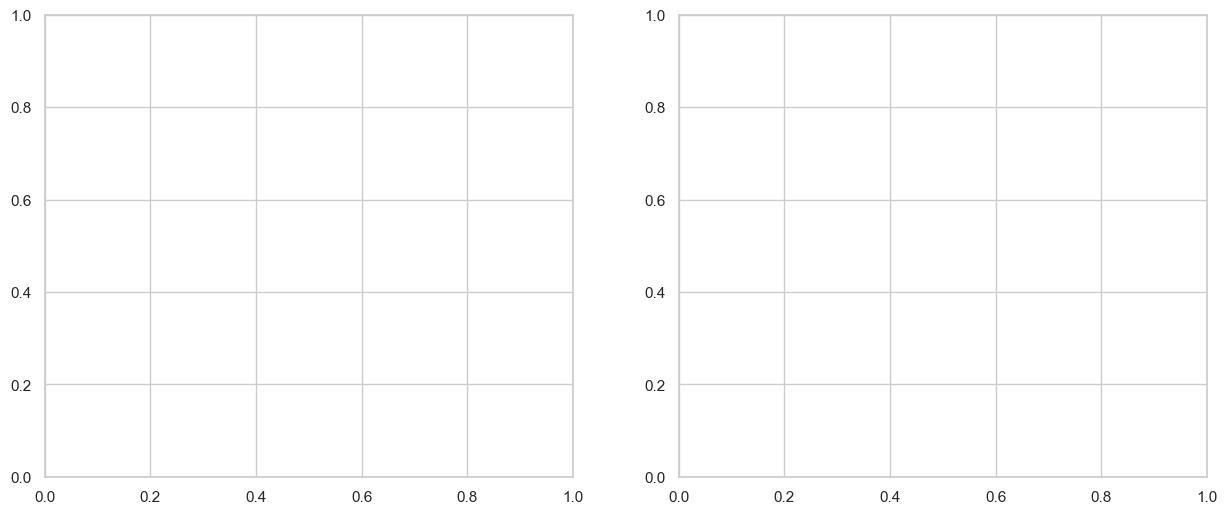

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('adagram_logs.csv')
lr_values = df['lr'].unique()

for lr in lr_values:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    subset = df[df['lr'] == lr]
    # for param in subset['param_id'].unique():
    param_subset = subset[subset['param_id'] == 1]
    # ax1.scatter(param_subset['step'], param_subset['max_U'], label=f'max_U (param {param})')
    # ax1.scatter(param_subset['step'], param_subset['min_U'], label=f'min_U (param {param})')
    # ax2.scatter(param_subset['step'], param_subset['max_V'], label=f'max_V (param {param})')
    # ax2.scatter(param_subset['step'], param_subset['min_V'], label=f'min_V (param {param})')
    # ax3.scatter(param_subset['step'], param_subset['grad_norm'], label=f'grad_norm (param {param})')
    # ax1.scatter(param_subset['step'], param_subset['max_U'], label=f'max_U')
    # ax1.scatter(param_subset['step'], param_subset['min_U'], label=f'min_U')
    # ax2.scatter(param_subset['step'], param_subset['max_V'], label=f'max_V')
    # ax2.scatter(param_subset['step'], param_subset['min_V'], label=f'min_V')
    print(param_subset['step'])
    ax1.hist(param_subset['step'], param_subset['grad_std'], label=f'grad_std')
    ax2.hist(param_subset['step'], param_subset['grad_norm'], label=f'grad_norm')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Value')
    ax1.set_title('grad norm')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Step')
    ax2.set_ylabel('Value')
    ax2.set_title('grad std')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ax3.set_xlabel('Step')
    # ax3.set_ylabel('Value')
    # ax3.set_title('Grad Norm')
    # ax3.legend()
    # ax3.grid(True, alpha=0.3)

    plt.suptitle(f'Plots for lr={lr}')
    plt.tight_layout()
    plt.show()


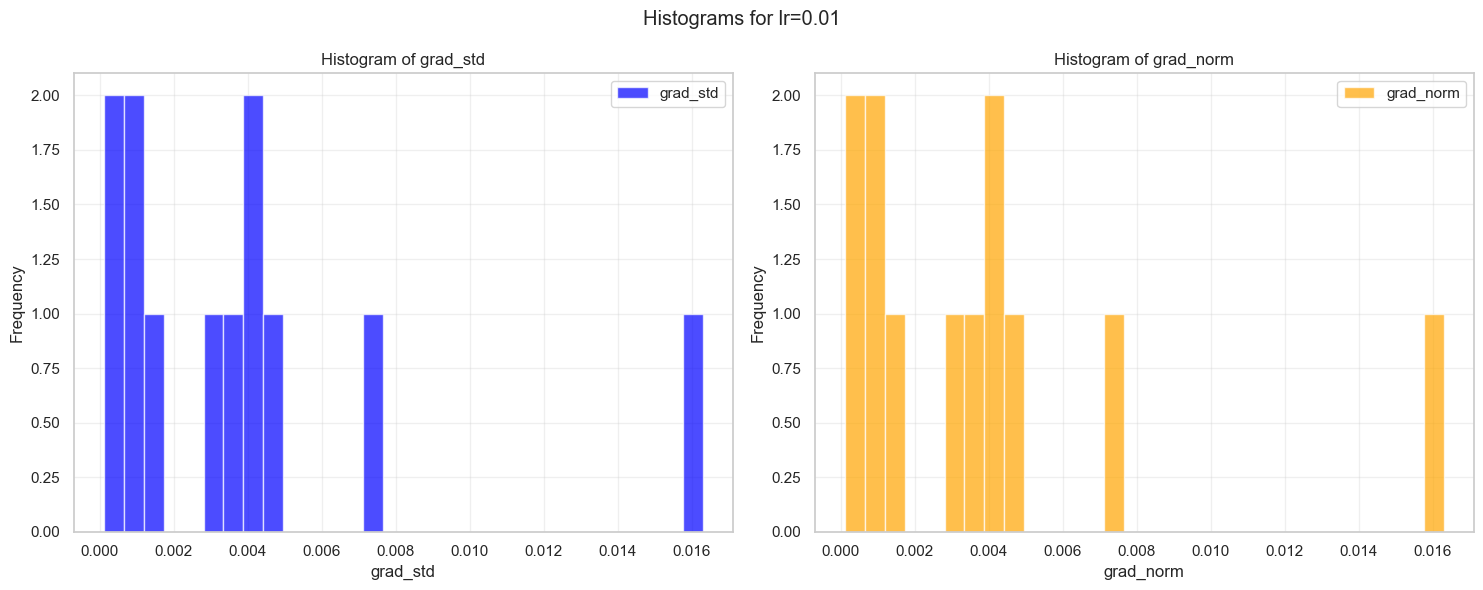

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('adagram_logs.csv')
lr_values = df['lr'].unique()

for lr in lr_values:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    subset = df[df['lr'] == lr]
    param_subset = subset[subset['param_id'] == 1]
    
    # Plot histogram of grad_std (only pass the data column)
    ax1.hist(param_subset['grad_std'], bins=30, color='blue', alpha=0.7, label='grad_std')
    ax1.set_xlabel('grad_std')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Histogram of grad_std')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot histogram of grad_norm (only pass the data column)
    ax2.hist(param_subset['grad_norm'], bins=30, color='orange', alpha=0.7, label='grad_norm')
    ax2.set_xlabel('grad_norm')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Histogram of grad_norm')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f'Histograms for lr={lr}')
    plt.tight_layout()
    plt.show()


UndefinedVariableError: local variable 'param' is not defined

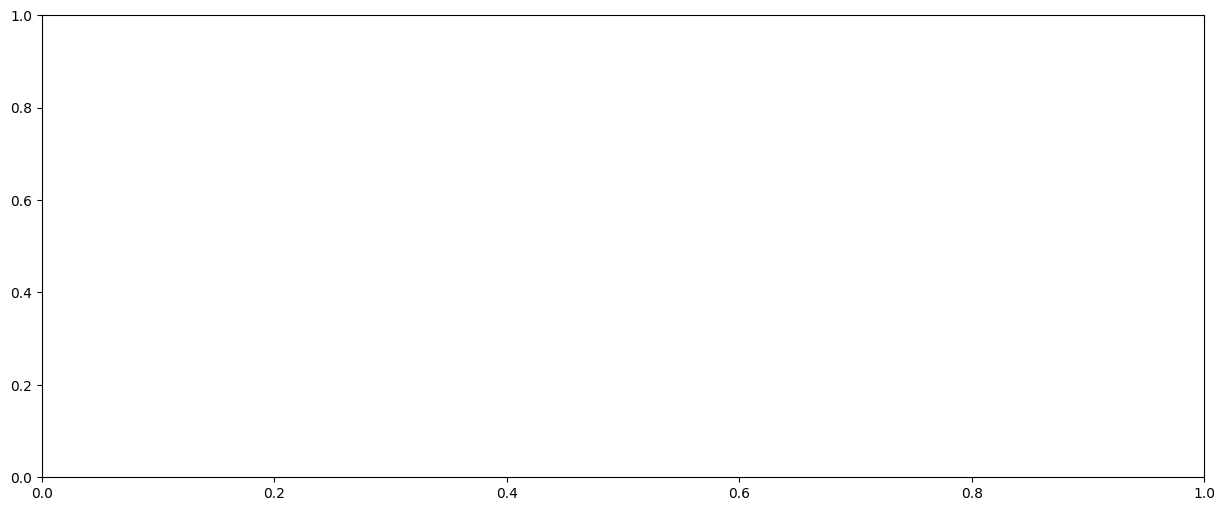

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('adagram_logs.csv')

# Create a single subplot
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

ax.scatter(df.query("param_id == @param")['step'], df.query("param_id == @param")['grad_norm'], marker='o', color='red', s=50, label='grad_norm')
ax.set_xlabel('Step')
ax.set_ylabel('Value')
ax.set_title('grad norm')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
